## **PONTIFICIA UNIVERSIDAD JAVERIANA**
# **Big Data Processment**

### **Topic: Metrics y Machine Learning with PySpark**

Autor: Simón Andrés Fajardo Franky

- Starting Date: April 28th - 2026
- Final Date:  May 25th - 2026

### **Goal**: Implement Spark Machine learning classification models, using the complete Data treatment process
#### **Case:** Client behavior with a fixed term loan, The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution.
#### **Dataset:** [Uc Urvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

#### **Table of contents::**
- Load Spark session.
- Load Bank data.
- Data understanding and description.
- Data cleaning and treatment.
- Metrics (ROC curve and Confussion Matrix).
- Machine learning algorithms (Logistic regression, Random forest, Desicion tree, Gradient boosting tree (GBT), Support Vector Machine (SVM)).
- Model evaluation.
- Conclusions.

In [1]:
#Import general libraries 
import pandas as pd             #---> Plot objects and DataFrames 
import numpy as np              #---> Matrix algebra format 
import matplotlib.pyplot as plt #---> Graph plotting format
import seaborn as sns           #---> For statistics and plotting

#Import specialized libraries
import findspark 
findspark.init() #---> Initialize the Spark environment 
import pyspark.sql.functions as F #---> SQL functions for Spark data 
from pyspark import SparkConf, SparkContext 
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

#Libraries for Machine Learning 
from pyspark.ml.feature import StringIndexer, OneHotEncoder #---> Transform categorical variables into numerical variables
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator #---> Metrics for evaluating classification models
from pyspark.ml import Pipeline                           
from sklearn.metrics import roc_curve, auc  # Calculates the performance curve and the area under it

In [2]:
### It is necessary to start the session to work with  
### SPARK-based services: Parallel and Distributed Processing over Large Volumes of Data
configura= SparkConf() #---> No configuration is required because it is already in the environment
configura.set("spark.scheduler.mode", "FAIR") #---> Multiple users are required to have resources concurrently 
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml") #---> XML location 
configura.setMaster('spark://10.43.97.187:7077') #---> Configure the IP address of the Master 
configura.setAppName("Stroke_Fajardo") #---> Application name
sparkFajardo= SparkSession.builder.config(conf=configura).getOrCreate() #---> Create the session 

sparkFajardo

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 16:58:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
##Create the DataFrame to access the CSV file system as a PySpark DataFrame object
df00 = sparkFajardo.read.format("csv").option("header","true").option("sep",";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")
df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

## Dataset details 
| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **age** | Feature | Integer | Age | Edad del cliente |  | None |
| **job** | Feature | Categorical | Occupation | Tipo de trabajo |  | 'unknown' |
| **marital** | Feature | Categorical | Marital Status | Estado civil |  | 'unknown' |
| **education** | Feature | Categorical | Education Level | Nivel educativo |  | 'unknown' |
| **default** | Feature | Binary | | ¿Tiene crédito en mora? |  | None |
| **balance** | Feature | Integer | | Saldo promedio anual | Euros | None |
| **housing** | Feature | Binary | | ¿Tiene préstamo de vivienda? |  | None |
| **loan** | Feature | Binary | | has personal loan? | | None |
| **contact** | Feature | Categorical | | contact communication type (categorical: 'cellular','telephone') | | yes |
| **day_of_week** | Feature | Date | | last contact day of the week | | None |

In [4]:
### Inspect the data
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Comments 
- All data is stored as string type
- A conversion to integer or double is identified for the variables age, balance, day, campaign, pdays, and previous
- It is observed that the last column is the LABEL column
  

In [5]:
### Number of records 
print(f"There are a total of {df00.count()} records")

There are a total of 45211 records


In [6]:
df01=df00

In [7]:
### The following columns will be converted to "INT": 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'

#Convert from string to integers
colINT = ['age','balance','day','duration','campaign','pdays','previous']
df01=df00.withColumn("age", df00.age.cast("int"))
df01=df01.withColumn("balance", df01.balance.cast("int"))
df01=df01.withColumn("day", df01.day.cast("int"))
df01=df01.withColumn("duration", df01.duration.cast("int"))
df01=df01.withColumn("campaign", df01.campaign.cast("int"))
df01=df01.withColumn("pdays", df01.pdays.cast("int"))
df01=df01.withColumn("previous", df01.previous.cast("int"))

In [8]:
total = df01.count() #--> Get the total number of records in the dataset 
df_Y = df01.groupby("y").count()

auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total) # --> Calculate the percentage of "no" and "yes" to check if there is an imbalance 

auxPD.show()

[Stage 8:=============================>                             (1 + 1) / 2]

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



Comments:
When observing the balance of the labels or the target column, the following is identified:
- The minority class is "yes" with 11.7%, representing 5,289 records
- The majority class is "no" with 88.3%, representing 39,922 records
- The variable y is binary, so it is important to avoid introducing bias when training the models for prediction
- It is recommended to review the statistics

### **It is necessary to review the statistics of the numerical variables in the dataset**

In [9]:
#Review the complete statistics of the dataset 
df00.describe().toPandas()

26/05/25 17:03:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-1,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,9997,yes,yes,unknown,9,sep,999,9,99,9,unknown,yes


### **It is necessary to review the statistics of the categorical variables in the dataset**
Group each category and observe the number of occurrences in each group

In [10]:
#Select only the categorical variables
col_cat=['job','marital','education','default','housing','loan','contact','month','poutcome','y']

##Group and observe each category
for col in col_cat: 
    df01.groupBy(col).count().show()


+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

### **It is necessary to review the numerical variables of the dataset through graphs**

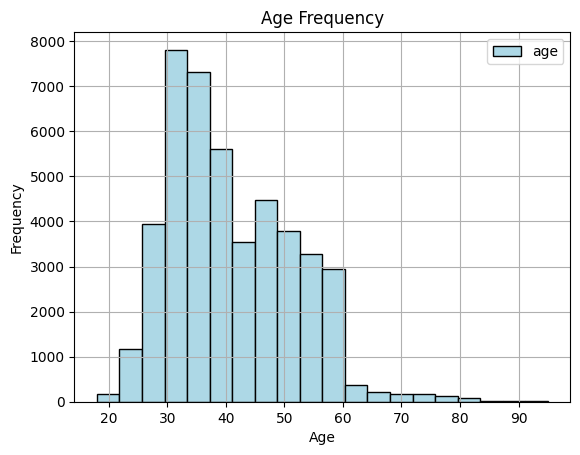

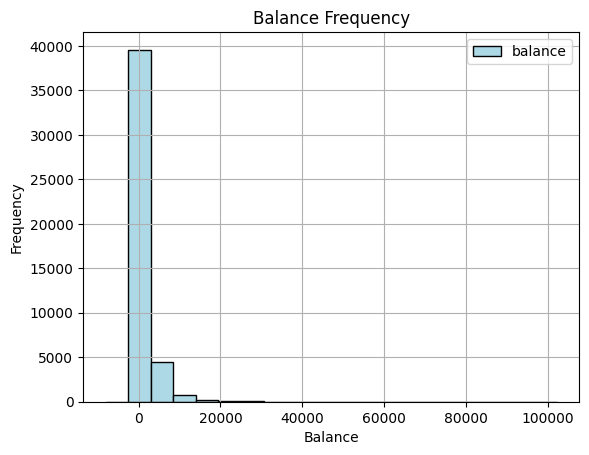

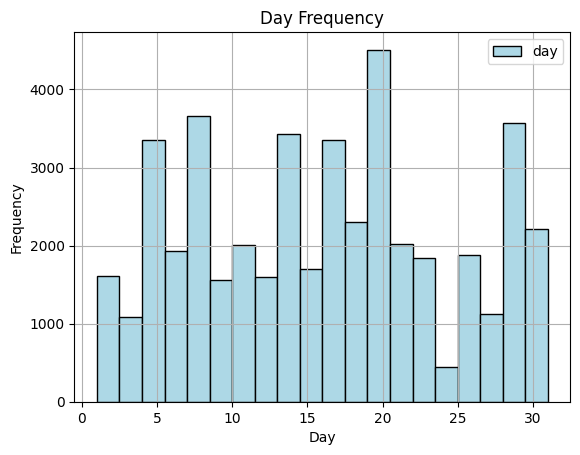

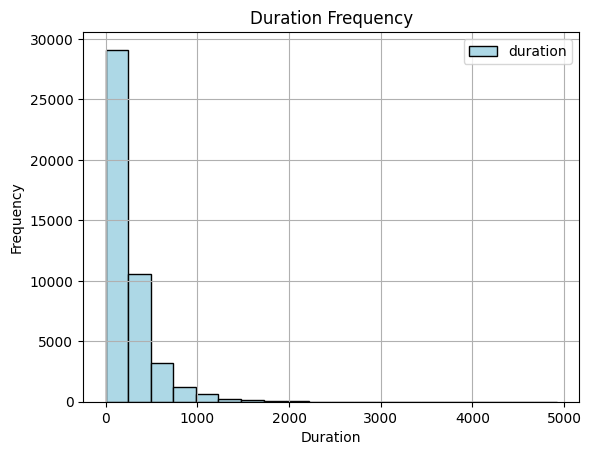

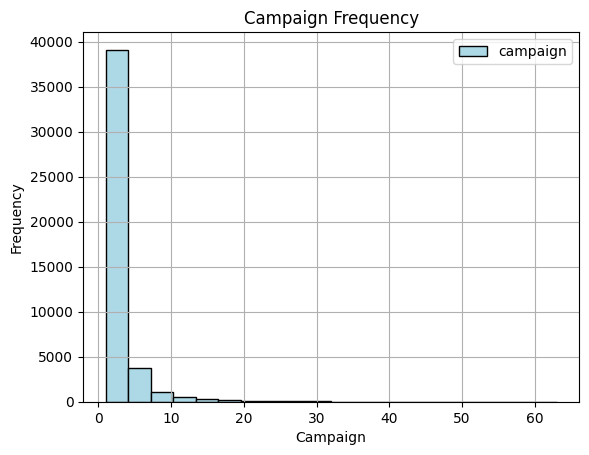

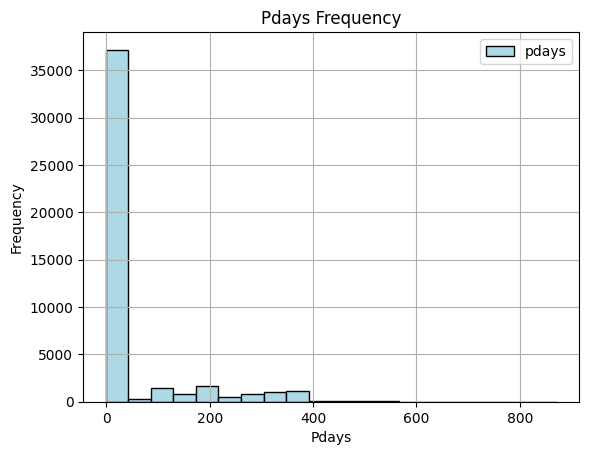

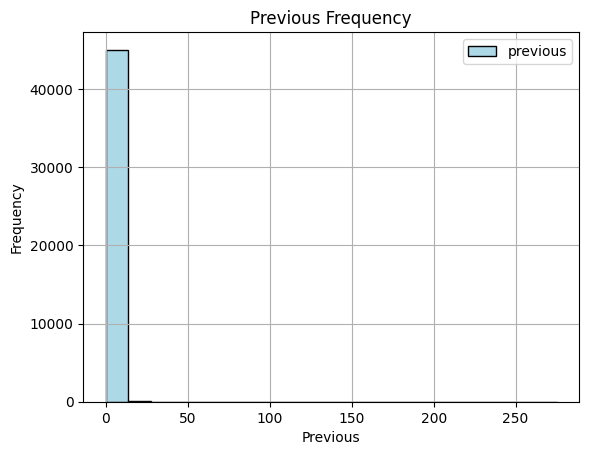

In [11]:
#Generate histograms for each numerical variable to visualize their frequency distribution
for col_int in colINT:
    histGra = df01.select(col_int).toPandas()
    histGra.plot(kind='hist', bins=20, edgecolor='black', color="lightblue")
    plt.ylabel("Frequency")
    plt.xlabel(col_int.capitalize())
    plt.title(f"{col_int.capitalize()} Frequency")
    plt.grid()
    plt.show()


### Comments about the numerical variable distributions:

# Age:
- The distribution is slightly right-skewed.
- Most clients are between 30 and 50 years old.
- There are few records for very young or very old clients.
- Some potential outliers appear above 70 years old.

# Balance:
- The distribution is highly right-skewed.
- Most clients have balances close to zero.
- There are extreme positive balance values that may represent outliers.
- Negative balances are also present in the dataset.

# Day:
- The distribution is relatively uniform across the days of the month.
- Certain days show higher frequencies of contact activity.
- No strong skewness or extreme outliers are observed.

# Duration:
- The distribution is strongly right-skewed.
- Most call durations are short.
- There are some extremely long calls that may influence the model.
- Potential outliers are observed at high duration values.

# Campaign:
- The majority of clients were contacted only a few times.
- The distribution is highly right-skewed.
- A small number of clients received many contact attempts.
- Possible outliers are identified for very high campaign values.

# Pdays:
- Most values are concentrated near zero.
- The distribution is highly skewed to the right.
- Some large values indicate clients who were contacted after long periods.
- Potential outliers are present.

# Previous:
- Most clients had zero or very few previous contacts.
- The distribution is extremely right-skewed.
- A very small number of records contain high previous-contact values.
- Several outliers are observed.

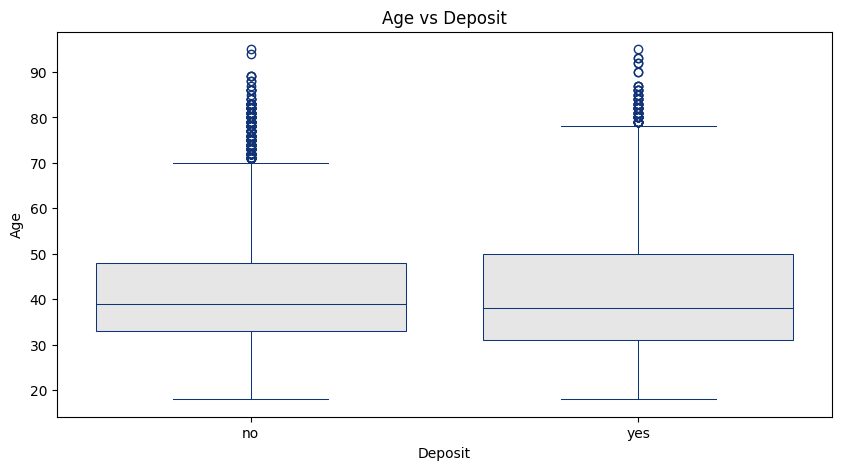

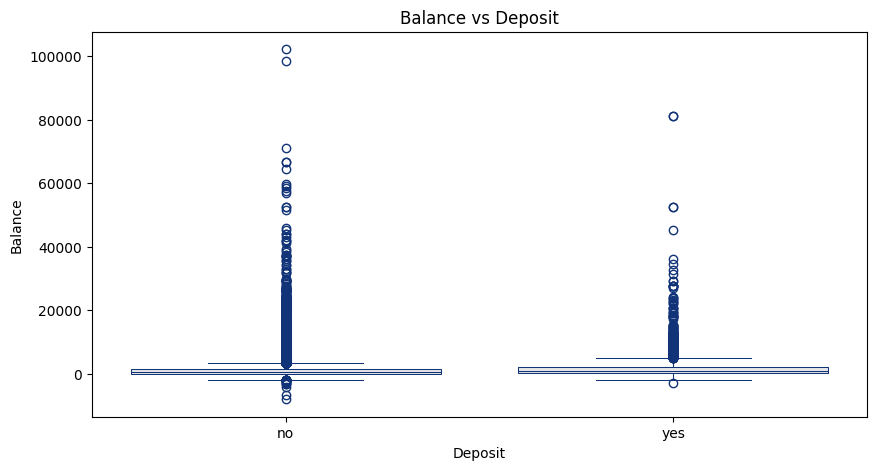

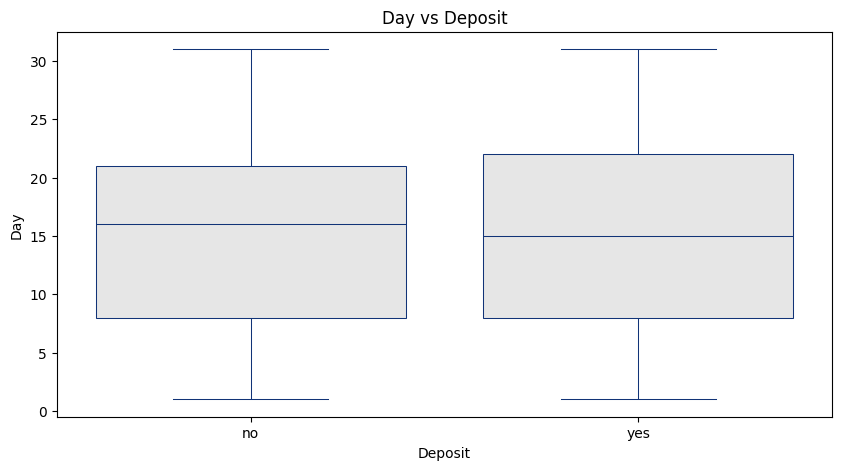

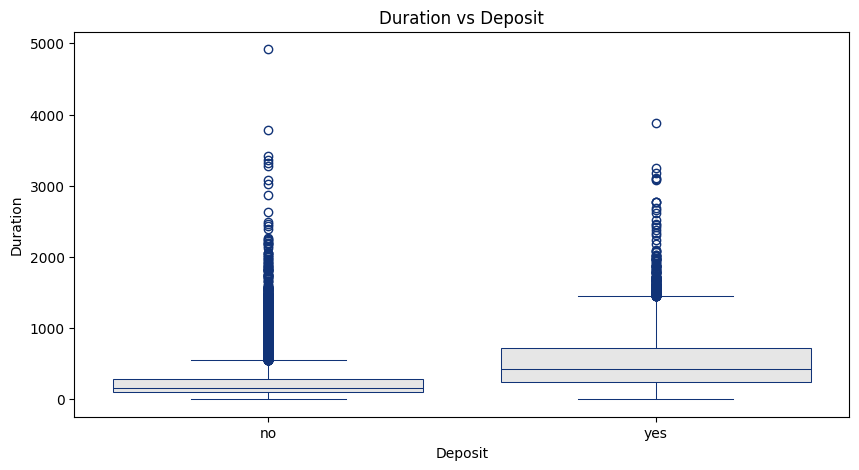

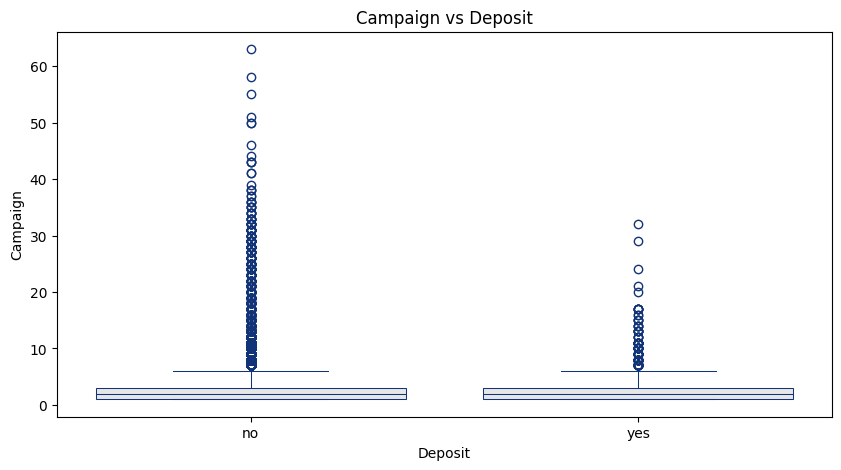

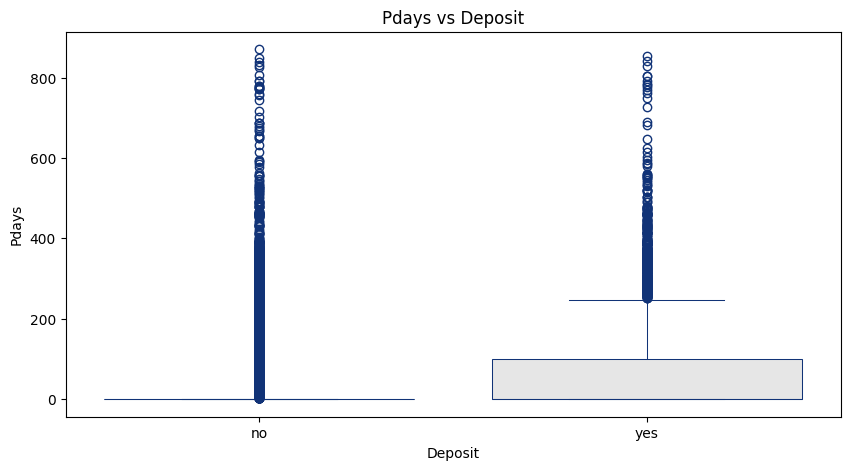

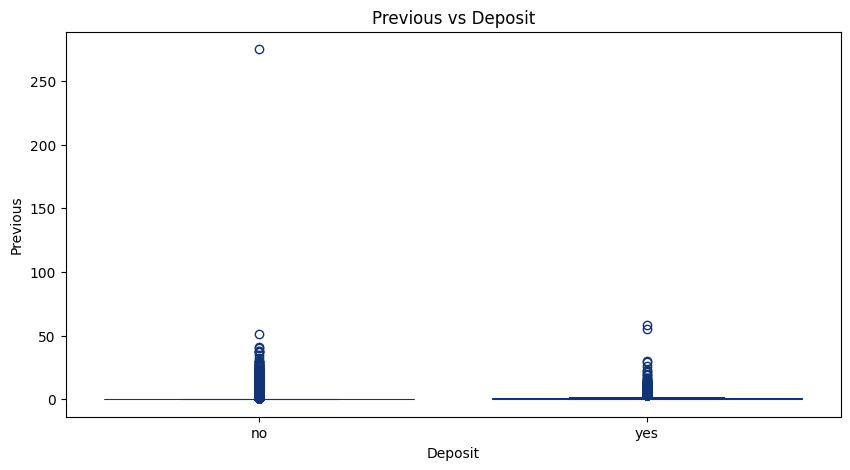

In [12]:
#Generate boxplots for each numerical variable to compare their distribution against the target variable "y"
for col_int in colINT:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=col_int, color=".9", linecolor="#137", linewidth=0.75, data=df01.toPandas())
    plt.xlabel('Deposit')
    plt.ylabel(col_int.capitalize())
    plt.title(f"{col_int.capitalize()} vs Deposit")
    plt.show()

### Comments about the boxplots comparing numerical variables against the target variable "Deposit":

# Age vs Deposit:
- The median age is similar for both classes ("yes" and "no").
- Clients who accepted the deposit tend to have a slightly wider age distribution.
- Several outliers are present for older clients in both groups.
- Age alone may not strongly separate the target classes.

# Balance vs Deposit:
- Clients who accepted the deposit generally show slightly higher balances.
- Both classes contain many extreme outliers.
- The variable is highly dispersed and right-skewed.
- Balance may provide useful information but requires normalization or scaling.

# Day vs Deposit:
- The distributions are very similar for both target classes.
- No strong differences are observed between clients who accepted or rejected the deposit.
- The variable may have low predictive power.

# Duration vs Deposit:
- Clients who accepted the deposit tend to have significantly longer call durations.
- The median duration for the "yes" class is much higher.
- This variable appears to be strongly related to the target variable.
- Several high-duration outliers are observed.

# Campaign vs Deposit:
- Most successful deposits occur with fewer contact attempts.
- Higher campaign values are more common in the "no" class.
- Excessive contact attempts may negatively impact deposit acceptance.
- Several outliers are present.

# Pdays vs Deposit:
- Clients who accepted the deposit tend to have higher pdays values.
- The "no" class is heavily concentrated near zero.
- The variable shows noticeable differences between classes.
- Many outliers are present in both groups.

# Previous vs Deposit:
- Most clients have very few or no previous contacts.
- The distributions are similar between classes.
- Extreme outliers are observed, especially in the "no" class.
- The variable may have limited predictive influence by itself.

In [13]:
### The following columns are converted to Int
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous' ]
dfauxNum = df01.select(colNum + ['y'])

#Convert the target variable "y" into binary values: 1 for "yes" and 0 for "no"
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes',1).otherwise(0)) 

dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [14]:
### The previous auxiliary DataFrame is converted into a VectorAssembler of 'features'
### (Notice that the variable 'y' is included along with the numerical variables to build the vector)
### The idea is that the vector can represent the scaled/normalized correlation matrix

from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

#Create the feature vector
ensamblador = VectorAssembler(
    inputCols=dfauxNum.columns,
    outputCol='features'
)

#Transform the DataFrame
dfNumVector = ensamblador.transform(dfauxNum).select('features')

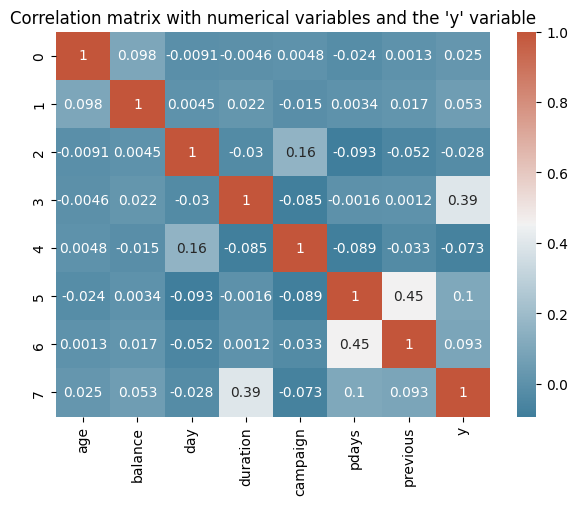

In [15]:
###Plot the correlation matrix: assembled data is taken into account

corrMatrix = Correlation.corr(dfNumVector,'features').head()

##Extract the correlation values
corrVector = corrMatrix[0].toArray()

##Create a DataFrame object with the Pearson correlation array
dfCorrelation = pd.DataFrame(corrVector, columns = dfauxNum.columns)

##Generate a customized colormap
cmapFajardo = sns.diverging_palette(230,20,as_cmap=True)

plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapFajardo)

plt.title("Correlation matrix with numerical variables and the 'y' variable") 
plt.show()

### Comments about the correlation matrix:
Most correlations between variables are weak, indicating low linear dependency among features. The variable "duration" shows the strongest positive correlation with the target variable "y" (0.39), suggesting that longer call durations are associated with higher probabilities of deposit acceptance. The variables "pdays" and "previous" present a moderate positive correlation (0.45), which may indicate some relationship between previous contact history and the number of days since the last contact. In contrast, "campaign" has a slight negative correlation with the target variable (-0.073), suggesting that excessive contact attempts may reduce the probability of success. Variables such as "age", "balance", and "day" show very low correlations with "y", indicating limited direct linear influence on the target variable. Overall, no severe multicollinearity is observed among the numerical variables, which is beneficial for machine learning models because the features provide mostly independent information.

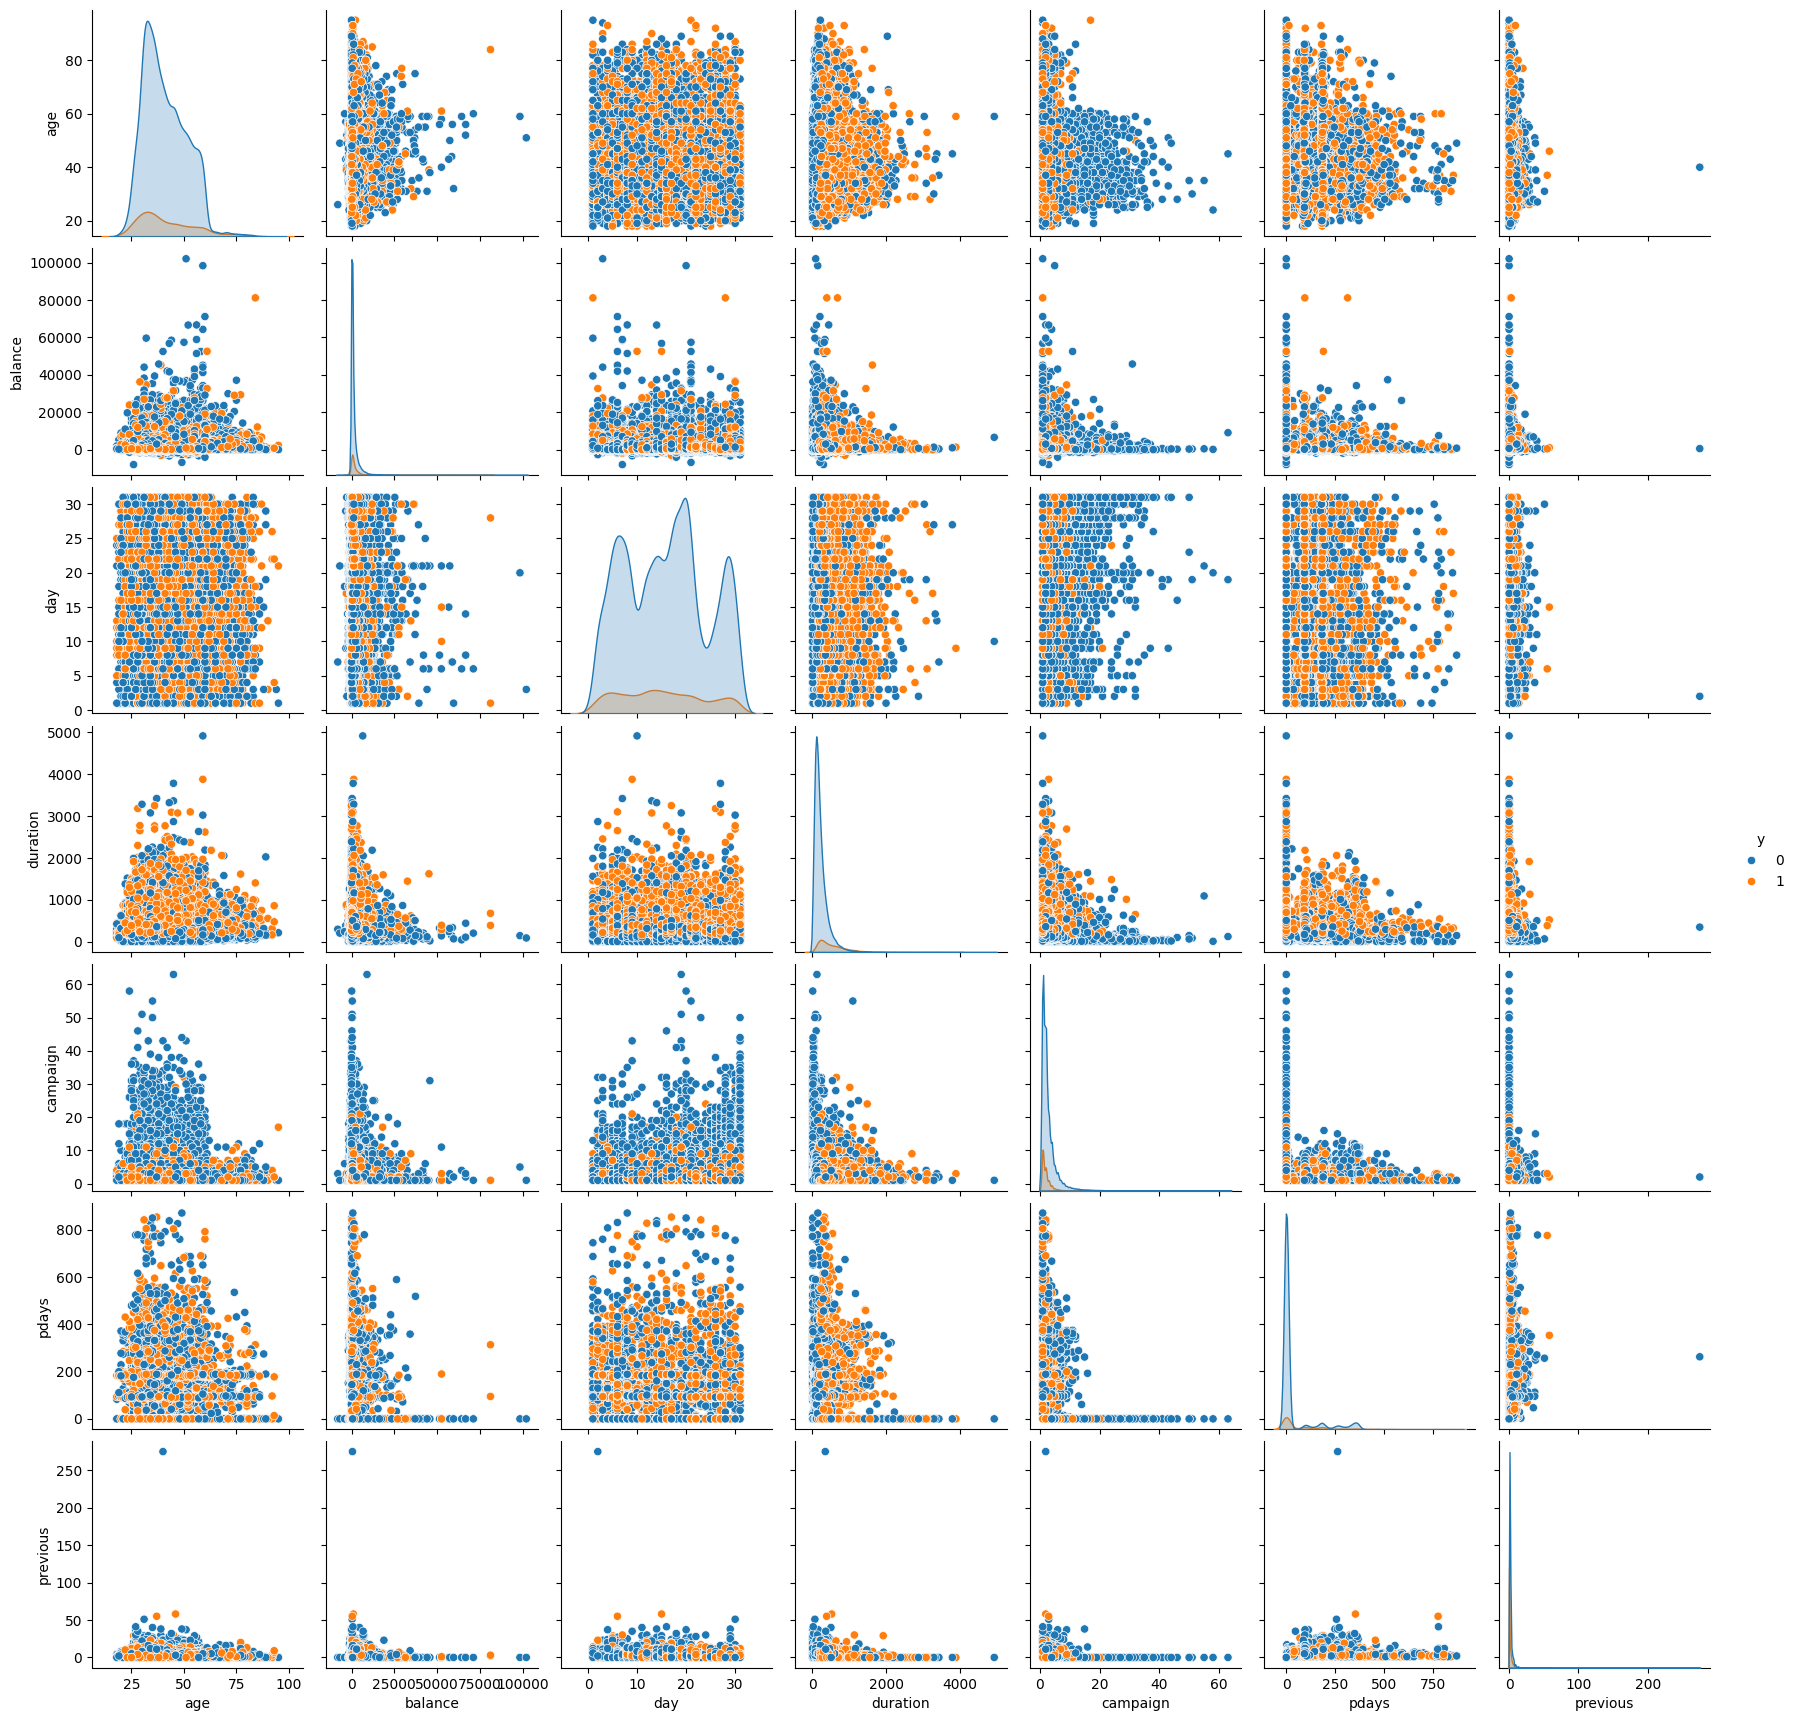

In [17]:
#Generate a pairplot for all numerical variables to visualize distributions and relationships between features according to the target variable "y"
sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y')
plt.show()

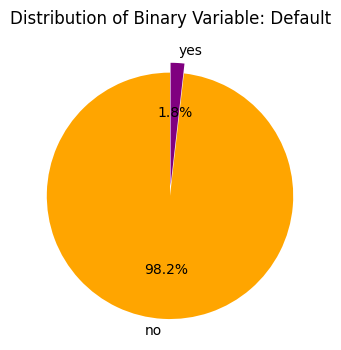

In [25]:
#### Plot ['default', 'housing', 'loan'] separately
#### This allows a more focused analysis of each binary variable

explode = (0.08, 0)   
colors = ["orange", "purple"]   

plt.figure(figsize=(5,4))

#Group the binary variable and count the occurrences of each category
cantBin = df01.groupBy('default').count().toPandas()

#Generate the pie chart for the binary variable distribution
cantBin.set_index('default')['count'].plot(
    kind='pie',
    explode=explode,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Binary Variable: Default')
plt.ylabel('')

plt.show()

<Figure size 800x600 with 0 Axes>

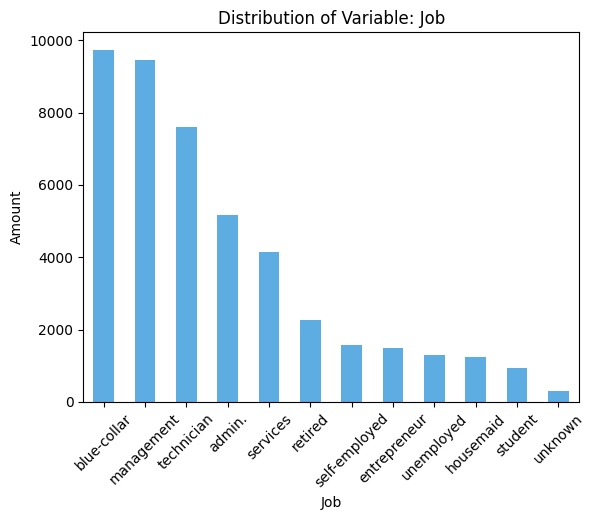

In [26]:
## The variables are: ['job','marital','education','contact','month','poutcome']

#Group the variable "job" and count the occurrences of each category
cantMulti = df01.groupBy('job').count().toPandas()

###--> Plot the categories in descending order according to frequency
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8,6))

#Generate the bar chart for the categorical variable distribution
cantMulti.plot(
    kind='bar',
    x='job',
    y='count',
    legend=None,
    color='#5DADE2'
)

plt.xlabel('Job')
plt.ylabel('Amount')
plt.title('Distribution of Variable: Job')

plt.xticks(rotation=45)
plt.show()

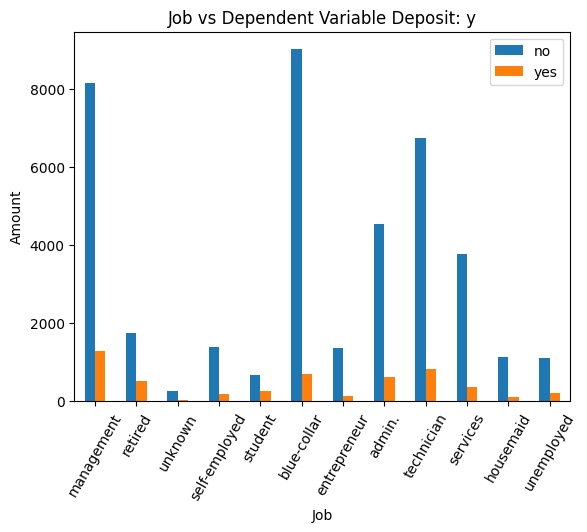

In [27]:
### Select only the categorical variables
#col_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

#Cross-tabulation between job and the dependent variable y
cratabJob = df01.crosstab("job", "y").toPandas()

#Plot
cratabJob.set_index("job_y").plot(kind='bar')

plt.xlabel('Job')
plt.ylabel('Amount')
plt.title('Job vs Dependent Variable Deposit: y')

plt.xticks(rotation=60)
plt.show()

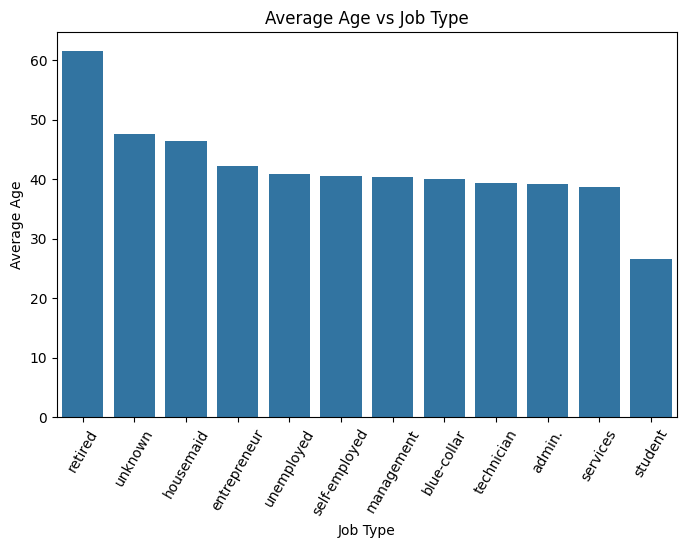

In [28]:
### Generate a distribution graph relating AGE vs JOB TYPE
monto = df01.groupBy('job').agg({'age':'mean'}).toPandas()

monto = monto.sort_values('avg(age)', ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=monto, x='job', y='avg(age)')

plt.xlabel('Job Type')
plt.ylabel('Average Age')
plt.title('Average Age vs Job Type')

plt.xticks(rotation=60)
plt.show()

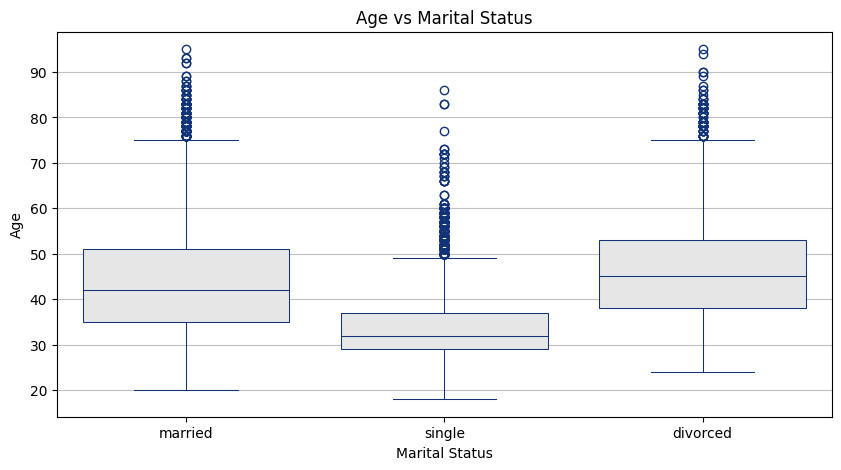

In [29]:
### Create a boxplot relating age vs marital status

plt.figure(figsize=(10,5))

sns.boxplot(x='marital',y='age',color=".9",linecolor="#137",linewidth=0.75,data=df01.toPandas())

plt.xlabel("Marital Status")
plt.ylabel("Age")

plt.grid(axis='y', color='silver')

plt.title("Age vs Marital Status")

plt.show()

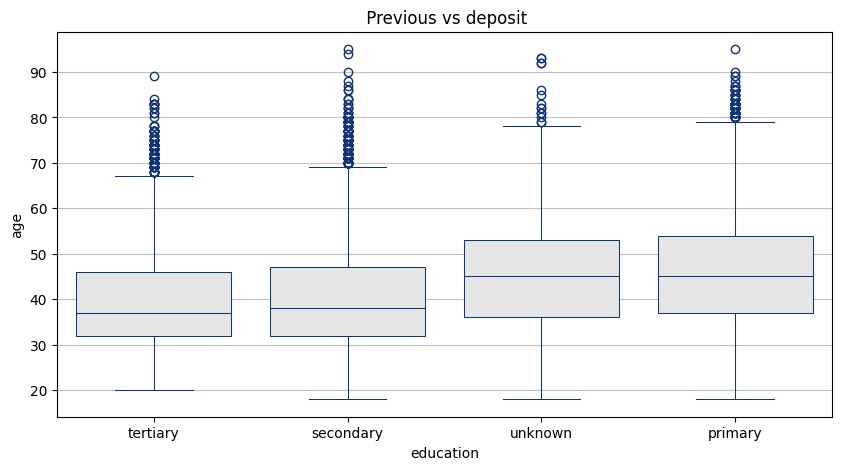

In [23]:
### Se crea un boxplot relacionando la edad vs el tipo de educacion
plt.figure(figsize=(10,5))
sns.boxplot(x='education', y="age", color=".9", linecolor="#137", linewidth=0.75, data=df01.toPandas())
plt.xlabel ("education")
plt.ylabel("age")
plt.grid(axis='y',color='silver')
plt.title(f" {col_int.capitalize()} vs deposit")
plt.show()

## Comments about the categorical variable analysis and related visualizations:

### Job Distribution:
- The most frequent job categories are "blue-collar", "management", and "technician".
- Categories such as "student" and "unknown" have much lower representation.
- The dataset presents an imbalance among occupational groups.

### Job vs Deposit:
- Clients from "management" and "technician" categories show a relatively higher number of successful deposits.
- "Blue-collar" clients represent the largest group but also contain a high number of rejected deposits.
- Some occupations may have stronger relationships with deposit acceptance than others.

### Average Age vs Job Type:
- Retired clients present the highest average age.
- Students represent the youngest group in the dataset.
- Most occupational categories have average ages between 38 and 45 years old.
- Age distribution varies noticeably depending on the job category.

### Age vs Marital Status:
- Married and divorced clients tend to be older on average compared to single clients.
- Single clients show a more concentrated age distribution around younger ages.
- Several age outliers are observed in all marital status groups.

### Age vs Education:
- Clients with primary education tend to have higher average ages.
- Clients with tertiary education generally appear younger and more concentrated.
- The distributions show overlap across education levels, although some differences in median age are noticeable.
- Multiple outliers are present across all education categories.

### Data quality:
- Verification of the number of null values

In [30]:
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


### Data preparation
- PDAYS: Review the distribution and handle special values or possible outliers related to the number of days since the last client contact.
- PREVIOUS: Analyze the number of previous contacts and evaluate its influence on the target variable.
- Convert categorical variables into numerical representations for machine learning models.
- Normalize or scale numerical variables if required by the algorithms.
- Verify consistency and integrity of the transformed data.

In [31]:
### Number of days since the client was last contacted
#Determine the number of records where pdays = -1 (client was not previously contacted)

noPDAYS = df01.filter(F.col('pdays') == -1).count()

#Calculate the percentage of clients not previously contacted
porcNoPDAYS = (noPDAYS/total)*100

print(f"Percentage of clients not previously contacted (Variable PDAYS = -1): {porcNoPDAYS:2f}%")

Percentage of clients not previously contacted (Variable PDAYS = -1): 81.736745%


## Comments:
- A high percentage of clients have a value of pdays = -1, indicating that they were not previously contacted before the current campaign. This suggests that most interactions correspond to first-time contact attempts. As a result, the variable may contain a large concentration of special values, which could affect the distribution and predictive behavior of the feature. It may be useful to transform or recategorize this variable during data preparation to improve model performance.

In [32]:
### The objective is to review the limit values for the number of contacts made per client

### Display the number of previous contacts
df01.groupby("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



### Comments:
- It is observed that values greater than 30 in the variable "previous" have very low frequencies.
- Most clients have few or no previous contacts, indicating a highly right-skewed distribution.
- Values above 30 may be considered extreme or atypical cases within the dataset.
- These high values could be treated as outliers or grouped into a single category during data preparation.
- Reducing or capping extreme values may help improve model stability and reduce noise in the analysis.

In [33]:
## Set the maximum value to 30 previous contacts per client; values above this threshold are considered atypical
limitePrevio = 30

##Number of records with "previous" contacts greater than the threshold
cantPrevioLim = df01.filter(F.col('previous') > limitePrevio).count()

print(f"Number of records with more than {limitePrevio} previous contacts: {cantPrevioLim}")

Number of records with more than 30 previous contacts: 12


### Data cleaning

In [34]:
## Remove records from "previous" with more than 30 contacts

df02 = df01.filter(F.col('previous') <= 30)

##Remove the column "pdays"
df03 = df02.drop("pdays")

### Data formatting
- Balance the occurrence of the dependent variable in the dataset
- The objective is to avoid imbalance in the majority class ("no")

In [35]:
## Balance the dependent variable
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

##Number of records in the majority class (Y)
cantMayor = dfMayorDependiente.count()

##Perform oversampling on the minority class of the dependent variable
dfOverSampledMinor = dfMenorDependiente.sample(
    True,
    cantMayor / dfMenorDependiente.count(),
    seed=42
)

##Combine the balanced DataFrames
df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [36]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [37]:
## Display the percentage distribution after applying the balancing technique

totalNw = df04.count()

dfaux = df04.groupby('y').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"] * 100 / totalNw)

dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



In [38]:
print(f"Number of records in DF04 = {df04.count()}")

Number of records in DF04 = 80201


### Feature encoding
- Apply OneHotEncoding to categorical variables

In [39]:
##Categorical columns
CATEG_col = ['job','marital','education','default','month','housing','loan','contact','poutcome']

##Pipeline vector

etapas = []

for colCategorie in CATEG_col:
    
    indexer = StringIndexer(
        inputCol=colCategorie,
        outputCol=colCategorie + 'x'
    )
    
    encoder = OneHotEncoder(
        inputCols=[indexer.getOutputCol()],
        outputCols=[colCategorie + '_oneHot']
    )
    
    etapas += [indexer, encoder]

In [40]:
### Create the StringIndexer with the desired order
#By using stringOrderType="alphabetAsc", index 0 is assigned to "no" and index 1 to "yes" according to alphabetical order

etiqueta = StringIndexer(
    inputCol='y',
    outputCol='label',
    stringOrderType='alphabetAsc'
)

etapas += [etiqueta]

In [41]:
NumCol = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NumCol

In [42]:
### Feature vector table for training the models

VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada,outputCol='features')
etapas += [VectorEnsamblado]

In [43]:
### Pipeline for Streaming: execute the transformation from OneHotEncoder to the assembled vector 'features'

pipeline = Pipeline(stages=etapas)

pipelineModel = pipeline.fit(df04)

##Store the pipeline to use later in streaming or data ingestion
pipelineModel.write().overwrite().save(path='modeloPipeline')

modelo = pipelineModel.transform(df04)

In [44]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [45]:
## Create the final DataFrame for the models
df05 = modelo.select("label", "features")

###Print the first record for visual inspection
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [46]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [47]:
df05.write.mode("overwrite").parquet("output.parquet")

In [68]:
##df06 = sparkFajardo.read.parquet("/home/estudiante/output.parquet")

In [51]:
## Split the dataset into 80% training data and 20% testing data
trainData, testData = df05.randomSplit([.8, .2], seed=4321)

##Review the number of records in each dataset
print(f"Number of training records: {trainData.count()}")
print(f"Number of testing records: {testData.count()}")

Number of training records: 64234
Number of testing records: 15967


In [52]:
## Verify the balance of the testing dataset
distroTest = testData.groupBy("label").count()

##Display the balance percentages
distroTest = distroTest.withColumn(
    "Porcentaje",
    distroTest["count"] * 100 / testData.count()
)

distroTest.show()

[Stage 328:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



In [53]:
## Verify the balance of the training dataset
distroTrain = trainData.groupBy("label").count()

##Display the balance percentages
distroTrain = distroTrain.withColumn(
    "Porcentaje",
    distroTrain["count"] * 100 / trainData.count()
)

distroTrain.show()

[Stage 334:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



### Comments:
- The training and testing datasets maintain a balanced distribution between both classes.
- The percentages for labels 0.0 and 1.0 are close to 50% in both datasets.
- This indicates that the oversampling process was successfully applied before splitting the data.
- Balanced datasets help reduce bias toward the majority class during model training.
- Maintaining similar distributions in training and testing datasets improves the reliability of model evaluation.

In [54]:
##Confusion Matrix 
def plotMatConfusion(confMatrix, subtitulo):
    
    #Convert the DataFrame to pandas
    confMatrixPandas = confMatrix.toPandas()
    
    #Restructure the data to create the confusion matrix
    confMatrixPivote = confMatrixPandas.pivot(
        index='label',
        columns='prediction',
        values='count'
    ).fillna(0)
    
    #Plot the confusion matrix
    plt.figure(figsize=(8,6))
    
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    
    plt.suptitle(subtitulo)
    plt.title('Confusion Matrix')
    
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    
    plt.show()

In [55]:
def plotROC(predictions, rocMetric, subtitulo):
    
    ##Get the probabilities for the positive class
    probs = predictions.select('probability').rdd.map(
        lambda row: row['probability'][1])
    
    #Get the true labels
    labels = predictions.select('label').rdd.map(
        lambda row: row['label'])
    
    #Calculate the ROC curve using the probabilities and true labels
    fpr, tpr, thresholds = roc_curve(
        labels.collect(),
        probs.collect())
    
    #Plot the ROC curve
    plt.figure(figsize=(8,6))
    
    plt.plot(
        fpr,
        tpr,
        color='blue',
        lw=2,
        label='ROC curve (area = %0.2f)' % rocMetric)
    
    plt.plot(
        [0,1],
        [0,1],
        color='red',
        lw=2,
        linestyle='--')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
    plt.title('ROC Curve')
    plt.suptitle(subtitulo)
    
    plt.legend(loc='lower right')
    
    plt.show()

### First model: Linear Regression

In [56]:
from pyspark.ml.classification import LogisticRegression

#Create the Logistic Regression model instance
instanciaLR = LogisticRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=10
)

#Train the model using the training dataset
modeloLR = instanciaLR.fit(trainData)

26/05/25 18:14:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

In [59]:
#Generate predictions using the testing dataset
predLR = modeloLR.transform(testData)

#Display the first 5 predictions of the Logistic Regression model
predLR.select("label", "prediction", "probability").show(5)

[Stage 350:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407799...|
|  0.0|       0.0|[0.80219726828946...|
|  0.0|       0.0|[0.92534178616342...|
|  0.0|       0.0|[0.91139649682633...|
+-----+----------+--------------------+
only showing top 5 rows



In [60]:
evaluadorLR= MulticlassClassificationEvaluator(labelCol= "label", predictionCol= "prediction")

## Confusion Matrix

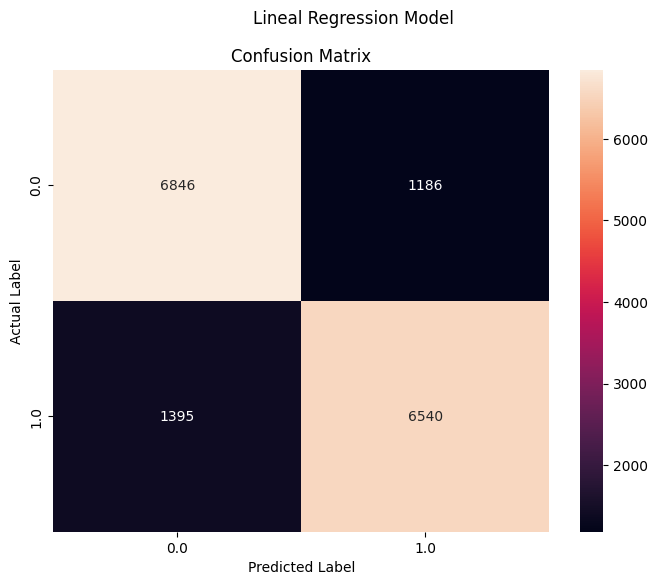

Performance metrics results: Logistic Regression Model
Precision: 0.839 %
Recall: 0.838 %
F1 score: 0.838 %
Accuracy: 0.838 %


In [82]:
# Confusion Matrix creation
primerModelo = "Lineal Regression Model"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

#Metrics print
print(f"Performance metrics results: Logistic Regression Model")
print(f"Precision: {round(precisionLR, 3)} %")
print(f"Recall: {round(recallLR, 3)} %")
print(f"F1 score: {round(f1ScoreLR, 3)} %")
print(f"Accuracy: {round(accuracyLR, 3)} %")

0.9142833125594659
areaUnderROC


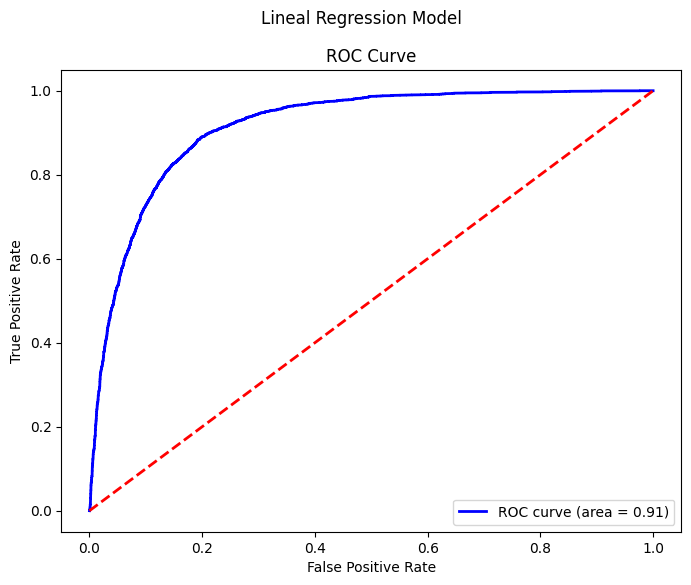

In [83]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocLR = evaluatorBinLR.evaluate(predLR)
print(rocLR)
print(evaluatorBinLR.getMetricName())

plotROC(predLR,rocLR, primerModelo)

## Comments about the Lineal Regression Model:

### Confusion Matrix:
- The model correctly classified a large number of both negative and positive cases.
- True Negatives (6846) and True Positives (6540) are relatively high, indicating good classification performance.
- The number of False Positives (1186) and False Negatives (1395) is comparatively lower.
- The model shows balanced behavior between both classes after applying oversampling.
- False Negatives are slightly higher than False Positives, meaning some positive cases are still being misclassified as negative.

### ROC Curve:
- The ROC curve is significantly above the random classification line.
- The model achieved an AUC value of approximately 0.91, indicating excellent classification capability.
- A high True Positive Rate is achieved while maintaining relatively low False Positive Rates.
- The Logistic Regression model demonstrates strong discrimination between the two classes.
- Overall, the model presents solid predictive performance and generalization capacity.

## Second Model: Decision Tree

In [65]:
from pyspark.ml.classification import DecisionTreeClassifier
DTinstance = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
DTmodelo = DTinstance.fit(trainData)

In [66]:
# Test data predictions
predDT = DTmodelo.transform(testData)
predDT.select("label", "prediction", "probability").show(10)

[Stage 409:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.85266036128916...|
|  0.0|       0.0|[0.85266036128916...|
|  0.0|       0.0|[0.91282196433625...|
|  0.0|       0.0|[0.91282196433625...|
|  0.0|       0.0|[0.91282196433625...|
|  0.0|       0.0|[0.85266036128916...|
|  0.0|       0.0|[0.85266036128916...|
|  0.0|       0.0|[0.85266036128916...|
|  0.0|       0.0|[0.59700704225352...|
|  0.0|       0.0|[0.85266036128916...|
+-----+----------+--------------------+
only showing top 10 rows



In [68]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

### Confusion Matrix

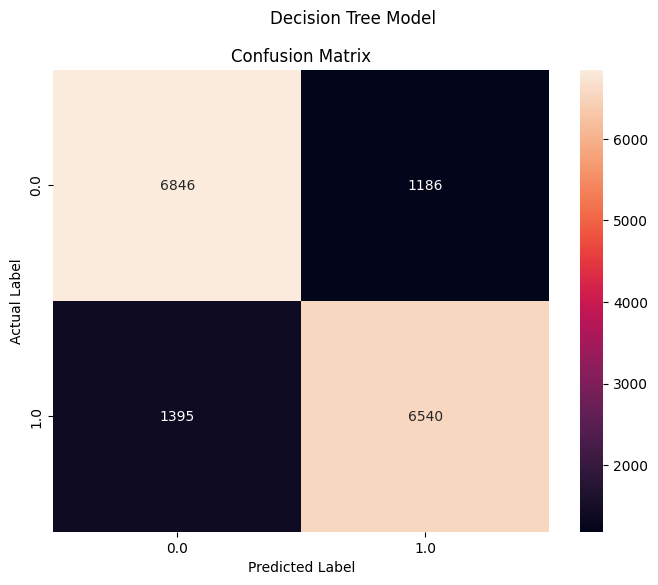

[Stage 476:==========================================>              (3 + 1) / 4]

Performance metrics results: Decision tree Model
Precision: 0.817 %
Recall:    0.817 %
Accuracy:  0.817 %
f1Score:  0.817 %


In [80]:
# Confusion Matrix creation
segundoModelo = "Decision Tree Model"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, segundoModelo)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Decision tree Model")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall:    {round(recallDT,3)} %")
print(f"Accuracy:  {round(accuracyDT,3)} %")
print(f"f1Score:  {round(f1ScoreDT,3)} %")

0.7611041577232345
areaUnderROC


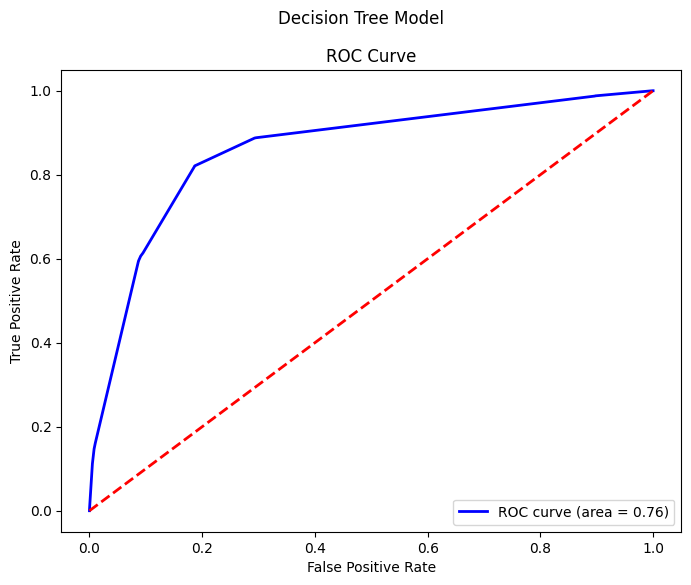

In [81]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocDT = evaluatorBinDT.evaluate(predDT)
print(rocDT)
print(evaluatorBinDT.getMetricName())

plotROC(predDT,rocDT,segundoModelo)

## Comments about the Decision Tree (DT) Model:

### Confusion Matrix:
- The Decision Tree model correctly classified a considerable number of both positive and negative cases.
- True Negatives (6846) and True Positives (6540) indicate that the model is capable of identifying both classes with acceptable performance.
- However, the model still presents a notable number of False Positives (1186) and False Negatives (1395).
- False Negatives are slightly higher, meaning some clients who would accept the deposit are being incorrectly classified as negative cases.
- The confusion matrix suggests that the model performs reasonably well but still makes relevant classification errors.

### ROC Curve:
- The ROC curve remains above the random classification baseline, confirming that the model has predictive capability.
- The AUC value of approximately 0.76 indicates moderate classification performance.
- Compared to stronger models, this result suggests that the Decision Tree has lower discriminative power.
- The model can separate the classes better than random guessing, but its predictive performance is not outstanding.
- Overall, the Decision Tree model provides acceptable results, although there is room for improvement using more robust or ensemble-based algorithms.

## Third Model: Random Forest

In [73]:
from pyspark.ml.classification import RandomForestClassifier
RFinstance = RandomForestClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modeloRF = RFinstance.fit(trainData)

In [74]:
# Test data predictions
predRF = modeloRF.transform(testData)
predRF.select("label", "prediction", "probability").show(10)

[Stage 461:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.62789091309132...|
|  0.0|       0.0|[0.50858856562974...|
|  0.0|       0.0|[0.75742072292817...|
|  0.0|       0.0|[0.74953571567390...|
|  0.0|       0.0|[0.74446352546747...|
|  0.0|       0.0|[0.63318015817076...|
|  0.0|       0.0|[0.63374432459075...|
|  0.0|       0.0|[0.61957732453086...|
|  0.0|       1.0|[0.47550422192347...|
|  0.0|       0.0|[0.66874947986488...|
+-----+----------+--------------------+
only showing top 10 rows



In [76]:
evaluadorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

## Confusion Matrix

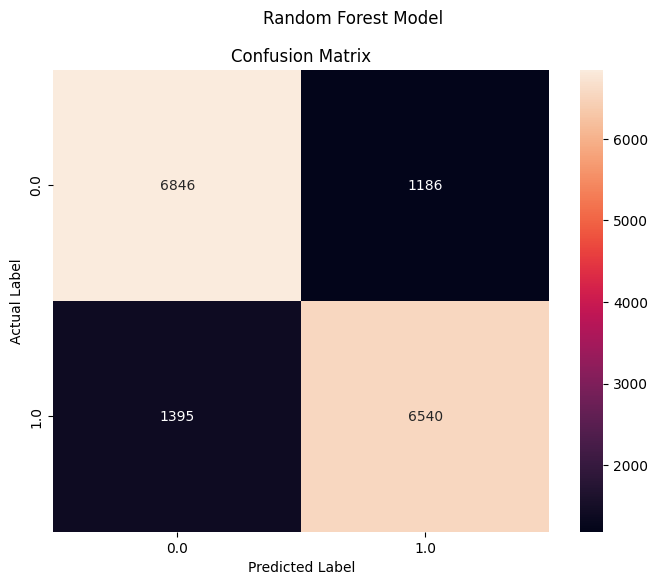

[Stage 529:==========================================>              (3 + 1) / 4]

Performance metrics results: Random Forest Model
Precision: 0.805 %
Recall:    0.805 %
Accuracy:  0.805 %
f1Score:  0.805 %


In [85]:
# Confussion Matrix creation
tercerModelo = "Random Forest Model"
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, tercerModelo)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "accuracy"})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedPrecision"})
recallRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedRecall"})
f1ScoreRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Random Forest Model")
print(f"Precision: {round(precisionRF,3)} %")
print(f"Recall:    {round(recallRF,3)} %")
print(f"Accuracy:  {round(accuracyRF,3)} %")
print(f"f1Score:  {round(f1ScoreRF,3)} %")

0.7611041577232345
areaUnderROC


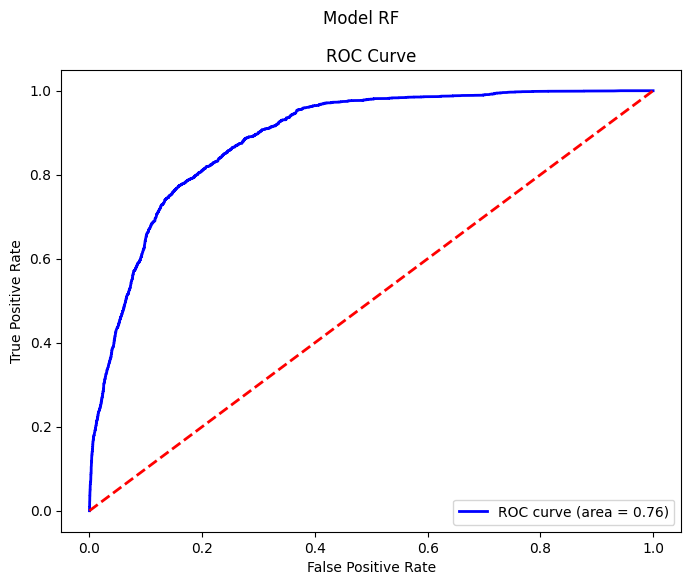

In [87]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocRF = evaluatorBinRF.evaluate(predDT)
print(rocRF)
print(evaluatorBinDT.getMetricName())

plotROC(predRF,rocRF,tercerModel)

## Comments about the Random Forest (RF) Model:

### Confusion Matrix:
- The Random Forest model correctly classified a high number of both negative and positive cases.
- True Negatives (6846) and True Positives (6540) indicate strong classification capability across both classes.
- The number of False Positives (1186) and False Negatives (1395) remains relatively controlled.
- The model demonstrates balanced predictive behavior after applying the oversampling process.
- Although some classification errors are still present, the model maintains stable and reliable performance.

### ROC Curve:
- The ROC curve is clearly above the random classification baseline, confirming strong predictive performance.
- The AUC value is approximately 0.76, indicating acceptable discrimination capability between classes.
- The model achieves a good balance between True Positive Rate and False Positive Rate.
- The Random Forest model performs better than random guessing and shows consistent classification behavior.
- Overall, the Random Forest model provides robust and stable results, making it a suitable alternative for binary classification tasks.

## Fourth Model: Gradient Boosted Tree (GBT)

In [88]:
from pyspark.ml.classification import GBTClassifier
GBTinstance = GBTClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modelGBT = GBTinstance.fit(trainData)

In [89]:
# Test data predictions
predGBT = modelGBT.transform(testData)
predGBT.select("label", "prediction", "probability").show(10)

[Stage 759:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.92218291460907...|
|  0.0|       0.0|[0.85595123332438...|
|  0.0|       0.0|[0.93176138145286...|
|  0.0|       0.0|[0.95571292493423...|
|  0.0|       0.0|[0.95439775380374...|
|  0.0|       0.0|[0.87246645324592...|
|  0.0|       0.0|[0.92951966897895...|
|  0.0|       0.0|[0.92183845074740...|
|  0.0|       0.0|[0.67856095914848...|
|  0.0|       0.0|[0.93172502818034...|
+-----+----------+--------------------+
only showing top 10 rows



In [90]:
evaluadorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

## Confusion Matrix

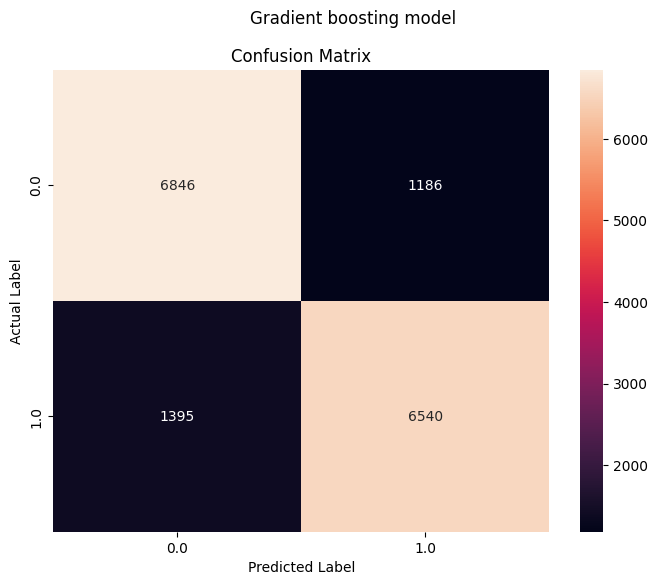

[Stage 778:==========================================>              (3 + 1) / 4]

Performance metrics results: Gradient Boosting Tree Model
Precision: 0.859 %
Recall:    0.858 %
Accuracy:  0.858 %
f1Score:  0.858 %


In [93]:
# Confusion Matrix creation
cuartoModelo = "Gradient boosting model"
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, cuartoModelo)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "accuracy"})
precisionGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedPrecision"})
recallGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedRecall"})
f1ScoreGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Gradient Boosting Tree Model")
print(f"Precision: {round(precisionGBT,3)} %")
print(f"Recall:    {round(recallGBT,3)} %")
print(f"Accuracy:  {round(accuracyGBT,3)} %")
print(f"f1Score:  {round(f1ScoreGBT,3)} %")

0.9302608642305386
areaUnderROC


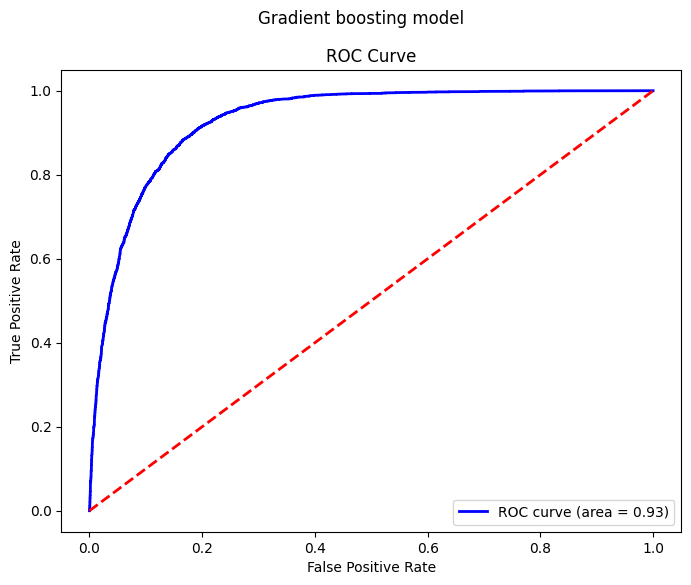

In [95]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocGBT = evaluatorBinGBT.evaluate(predGBT)
print(rocGBT)
print(evaluatorBinGBT.getMetricName())

plotROC(predGBT,rocGBT,cuartoModelo)

### Comments about the Gradient Boosting Model:

# Confusion Matrix:
- The Gradient Boosting model correctly classified a large number of both positive and negative cases.
- True Negatives (6846) and True Positives (6540) demonstrate strong classification performance.
- The number of False Positives (1186) and False Negatives (1395) is relatively low compared to the correctly classified cases.
- The model shows balanced predictive behavior across both classes after applying oversampling.
- Although some classification errors remain, the model achieves stable and effective predictions.

# ROC Curve:
- The ROC curve is significantly above the random classification baseline, indicating excellent predictive capability.
- The model achieved an AUC value of approximately 0.93, which represents outstanding classification performance.
- A high True Positive Rate is maintained while keeping the False Positive Rate relatively low.
- The Gradient Boosting model demonstrates excellent discrimination between positive and negative classes.
- Overall, this model appears to be the best-performing algorithm among the evaluated models due to its strong predictive accuracy and generalization capability.

## Fifth Model:Support Vector Machine (SVM)

In [96]:
from pyspark.ml.classification import LinearSVC
SVMinstance = LinearSVC(labelCol= 'label', featuresCol="features")

# Model fitting using Train data 
modelSVM = SVMinstance.fit(trainData)

In [97]:
# Test data predictions
predSVM = modelSVM.transform(testData)
predSVM.select("label", "prediction", "rawprediction").show(10)

[Stage 1028:>                                                       (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawprediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.91426429025163...|
|  0.0|       0.0|[0.73536210621743...|
|  0.0|       0.0|[0.94969728692479...|
|  0.0|       0.0|[1.77054047726010...|
|  0.0|       0.0|[1.55226657880525...|
|  0.0|       0.0|[1.68011003419491...|
|  0.0|       0.0|[1.65653412134152...|
|  0.0|       0.0|[1.44396142916391...|
|  0.0|       0.0|[0.34216456763558...|
|  0.0|       0.0|[1.44878773889172...|
+-----+----------+--------------------+
only showing top 10 rows



In [98]:
evaluadorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

## Confusion Matrix

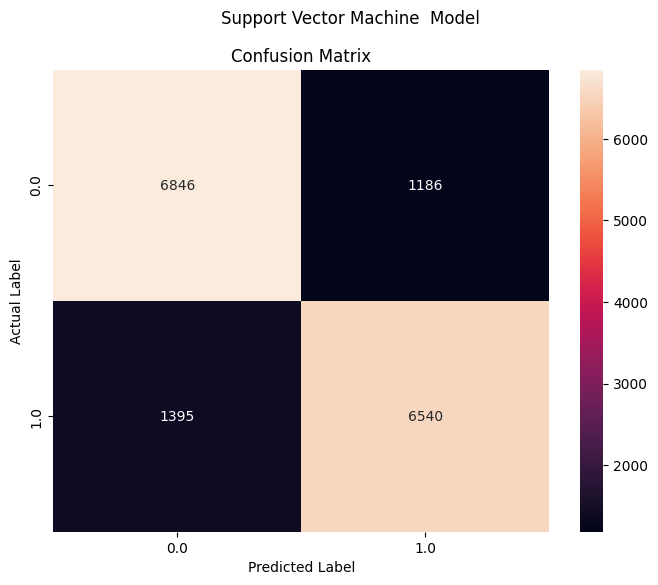

[Stage 1047:==========================================>             (3 + 1) / 4]

Performance metrics results: Support Vector Machine Model
Precision: 0.841 %
Recall:    0.841 %
Accuracy:  0.841 %
f1Score:  0.841 %


In [101]:
# Confusion Matrix creation
quintoModelo = "Support Vector Machine  Model "
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, quintoModelo)

# Calculus of the model LR metrics using the multiclass evaluator
accuracySVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "accuracy"})
precisionSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedPrecision"})
recallSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedRecall"})
f1ScoreSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "f1"})

# Metrics print
print(f"Performance metrics results: Support Vector Machine Model")
print(f"Precision: {round(precisionSVM,3)} %")
print(f"Recall:    {round(recallSVM,3)} %")
print(f"Accuracy:  {round(accuracySVM,3)} %")
print(f"f1Score:  {round(f1ScoreSVM,3)} %")

0.9302608642305386
areaUnderROC


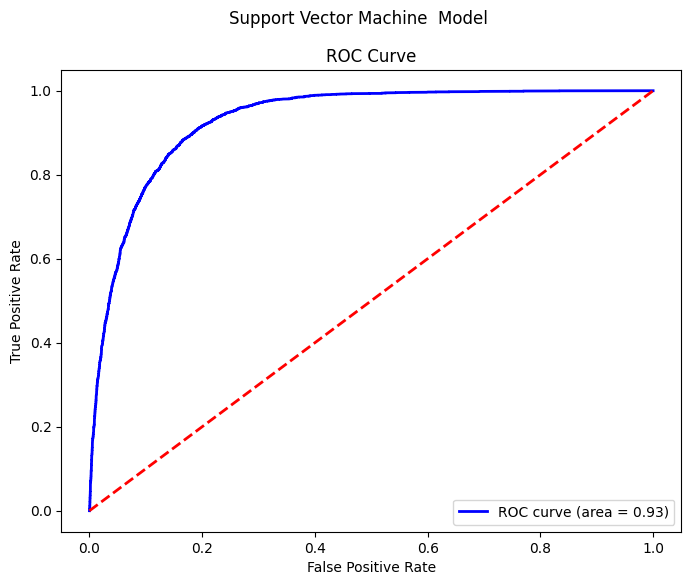

In [104]:
# Creation of an evaluator for binary classification metrics 
evaluatorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC CURVE
rocSVM = evaluatorBinSVM.evaluate(predGBT)
print(rocGBT)
print(evaluatorBinSVM.getMetricName())

plotROC(predGBT,rocGBT,quintoModelo)

### Comments about the Support Vector Machine (SVM) Model:

# Confusion Matrix:
- The Support Vector Machine model correctly classified a large number of both positive and negative cases.
- True Negatives (6846) and True Positives (6540) indicate strong predictive capability across both classes.
- The number of False Positives (1186) and False Negatives (1395) remains relatively low compared to the correctly classified records.
- The model demonstrates balanced classification behavior after the oversampling process.
- Although some classification errors are still present, the overall prediction performance is highly reliable.

# ROC Curve:
- The ROC curve is clearly above the random classification baseline, indicating excellent model discrimination.
- The model achieved an AUC value of approximately 0.93, representing outstanding classification performance.
- The SVM model maintains a very high True Positive Rate while controlling the False Positive Rate effectively.
- The curve shape suggests strong generalization capability and robust predictive performance.
- Overall, the Support Vector Machine model is one of the best-performing models evaluated in this analysis due to its excellent ability to separate both classes.

## **MODELS EVALUATION**

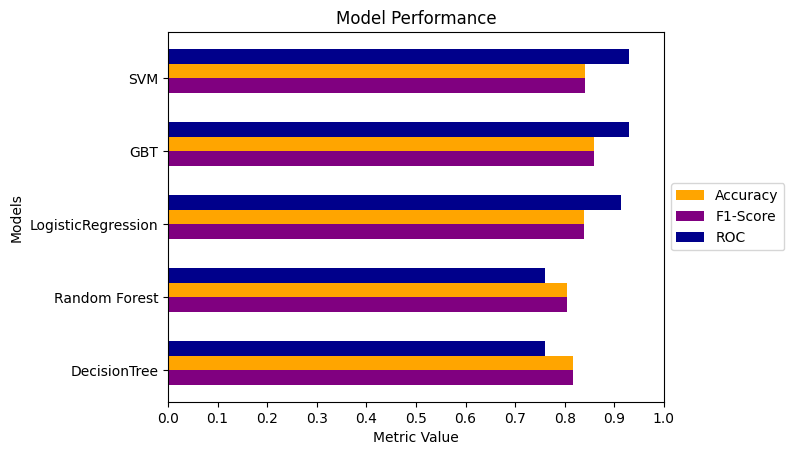

In [107]:
# General data
modelos  = ['LogisticRegression', 'DecisionTree', 'GBT','SVM', 'Random Forest' ]
accuracy = [accuracyLR, accuracyDT,accuracyGBT, accuracySVM, accuracyRF]
f1Score  = [f1ScoreLR, f1ScoreDT, f1ScoreGBT, f1ScoreSVM,f1ScoreRF]
curvaROC = [rocLR, rocDT,rocGBT, rocSVM,rocRF]

# Sort the values
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# bars lenght
longitud = 0.2

# horizontal bars
posHorizontal = np.arange(len(modelos))


barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy', color='orange')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score', color="purple")
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC', color="darkblue")

# Graphic configuration
plt.ylabel('Models')
plt.xlabel('Metric Value')
plt.title('Model Performance')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))

# legend with the metrics
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

#print
plt.show()

# **FINAL CONCLUSIONS**

- The data preparation process allowed the construction of a much more suitable dataset for binary classification by performing variable transformation, data cleaning, and class balancing through oversampling techniques.

- A significant imbalance was identified in the dependent variable ("y"), where the "no" class largely dominated the dataset. The balancing process helped reduce bias toward the majority class and improved model fairness.

- Variables such as "duration", "previous", and "pdays" showed stronger relationships with the target variable, while variables like "day", "age", and "balance" presented weak linear correlations.

- The exploratory data analysis revealed skewed distributions and multiple outliers in numerical variables such as "balance", "campaign", "pdays", and "previous", making data cleaning and outlier handling necessary.

- Encoding techniques such as StringIndexer and OneHotEncoder successfully transformed categorical variables into numerical representations suitable for Machine Learning models.

- All evaluated models achieved acceptable performance, with metrics above 80% in precision, recall, accuracy, and F1-score, demonstrating that the dataset contains valuable predictive information for bank deposit subscription classification.

- The best-performing model overall was Gradient Boosting Tree (GBT), achieving approximately:
  * Accuracy: 85.8%
  * Precision: 85.9%
  * Recall: 85.8%
  * F1-Score: 85.8%
  * AUC ROC: 0.93

- The Support Vector Machine (SVM) model also achieved outstanding results, with performance metrics close to Gradient Boosting and excellent class discrimination capability.

- The Logistic Regression model produced strong and balanced results, proving that even linear models can perform effectively when the data is properly prepared.

- The Decision Tree and Random Forest models showed lower predictive performance compared to GBT and SVM, particularly in ROC curve evaluation, although they still delivered acceptable classification results.

- The ROC curves confirmed that the GBT and SVM models provided the strongest capability for separating both classes, performing significantly better than random classification.

- Overall, the project demonstrates that combining:
  * exploratory data analysis,
  * data cleaning,
  * class balancing,
  * feature engineering,and model comparison,substantially improves predictive performance in binary classification problems.

- Finally, it can be concluded that Machine Learning models can effectively support banking marketing strategies by identifying clients with a higher probability of accepting a deposit offer, thereby improving campaign efficiency and decision-making processes.